### 1. Exploring the Impact of Sample Size on T-Distribution

**Problem Statement:**
Investigate the impact of sample size on the t-distribution through a Python program. Generate random samples of varying sizes from a standard normal distribution, compute t-statistics, and visually track the evolution of the t-distribution with increasing sample size. Provide an analysis report on the interpretation of the plots.

The t-distribution is similar in shape to the standard normal (Z) distribution, but it has heavier tails, meaning it has more probability in the tails and less in the center compared to the normal distribution. The exact shape of the t-distribution depends on the degrees of freedom (ν), which is a parameter that determines the distribution's variability.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

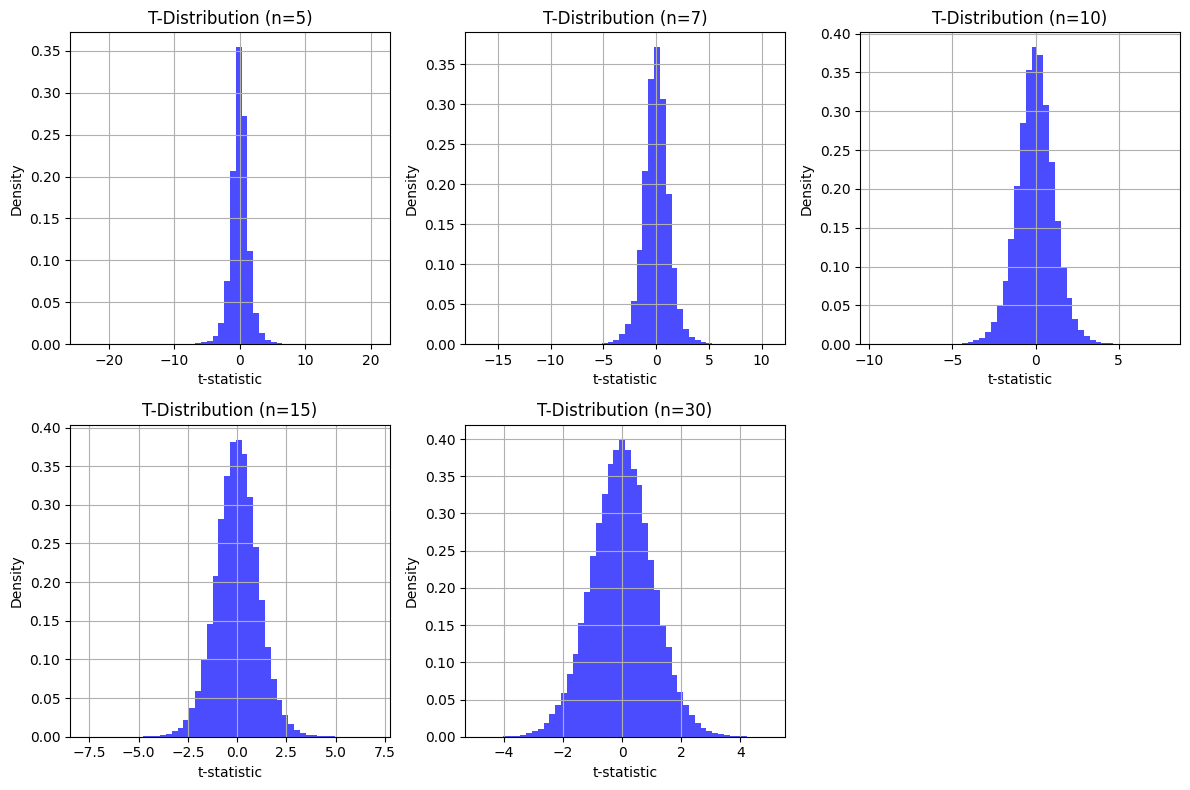

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import sys

# Parameters
sample_sizes = [5, 7, 10, 15, 30]  # List of sample sizes to investigate
num_samples = 100000  # Number of random samples generated for each sample size

# Generate random samples and compute t-statistics
t_distributions = []
for size in sample_sizes:
    # Generate random samples from a standard normal distribution
    samples = np.random.standard_normal((num_samples, size))

    # Compute t-statistics for each sample
    # Formula: sqrt(n) * (mean - population mean) / (sample standard deviation / sqrt(n))
    t_stats = np.sqrt(size) * (np.mean(samples, axis=1) - 0) / np.std(samples, axis=1, ddof=1)

    # Append t-statistics to the list
    t_distributions.append(t_stats)

# Plot the t-distributions for each sample size
plt.figure(figsize=(12, 8))
for i, size in enumerate(sample_sizes):
    plt.subplot(2, 3, i+1)

    # Plot histogram of t-statistics with 50 bins
    plt.hist(t_distributions[i], bins=50, density=True, alpha=0.7, color='blue')

    # Set title and labels
    plt.title(f'T-Distribution (n={size})')
    plt.xlabel('t-statistic')
    plt.ylabel('Density')

    plt.grid(True)  # Add grid lines to the plot

plt.tight_layout()  # Adjust layout to prevent overlap of subplots
plt.show()  # Display the plot

### old way plotting



# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import t, norm

# # Step 1: Generate random samples
# def generate_samples(sample_sizes):
#     return [np.random.randn(size) for size in sample_sizes]

# # Step 2: Compute t-statistics
# def compute_t_statistics(samples):
#     means = [np.mean(sample) for sample in samples]
#     stds = [np.std(sample, ddof=1) for sample in samples]  # ddof=1 for sample standard deviation
#     sizes = [len(sample) for sample in samples]

#     t_stats = [means[i] / (stds[i] / np.sqrt(sizes[i])) for i in range(len(samples))]
#     return t_stats

# # Step 3: Visualization
# def plot_t_distribution(samples, t_stats, sample_sizes):
#     x = np.linspace(-5, 5, 1000)

#     plt.figure(figsize=(12, 8))
#     for i, size in enumerate(sample_sizes):
#         plt.plot(x, t.pdf(x, df=size-1), label=f'Sample size: {size}', linewidth=1.5)
#         plt.axvline(t_stats[i], color='red', linestyle='--', linewidth=0.7)

#     plt.plot(x, norm.pdf(x), color='black', label='Standard Normal', linestyle='-')
#     plt.title('T-Distributions with Varying Sample Sizes')
#     plt.xlabel('Value')
#     plt.ylabel('Density')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# # Main program
# sample_sizes = [5, 10, 20, 30, 50, 100]
# samples = generate_samples(sample_sizes)
# t_stats = compute_t_statistics(samples)


### Plotting Z-distribution

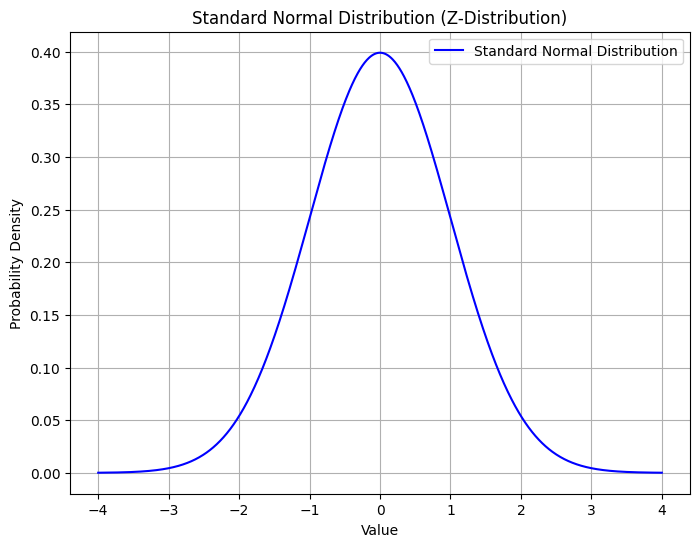

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate data points for the x-axis (range of values)
x = np.linspace(-4, 4, 1000)

# Compute the probability density function (PDF) for the standard normal distribution
y = norm.pdf(x, loc=0, scale=1)  # loc=0 (mean), scale=1 (standard deviation)

# Plot the standard normal distribution
plt.figure(figsize=(8, 6))
plt.plot(x, y, color='blue', label='Standard Normal Distribution')

# Add labels and title
plt.title('Standard Normal Distribution (Z-Distribution)')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()

# Show plot
plt.show()

The impact of sample size on the t-distribution is primarily seen in the shape and behavior of the distribution. As the sample size increases:

1. Decrease in Variability: The variability of the t-distribution decreases. This is because larger sample sizes provide more information about the population, resulting in more precise estimates of the population parameters. Consequently, the spread of the t-distribution becomes narrower, and the standard deviation decreases.  
2. Approaches Normality: The t-distribution approaches the standard normal distribution (a normal distribution with mean 0 and standard deviation 1). This phenomenon is in line with the central limit theorem, which states that as the sample size increases, the sampling distribution of the sample mean approaches a normal distribution regardless of the shape of the population distribution. Therefore, for sufficiently large sample sizes, the t-distribution becomes indistinguishable from the standard normal distribution.  
3. Symmetry and Bell-Shaped: The t-distribution becomes more symmetric and bell-shaped. With larger sample sizes, the t-distribution becomes increasingly similar in shape to the standard normal distribution, exhibiting a smooth and symmetrical curve.  
4. Convergence to Z-Distribution: In practice, as the sample size becomes very large (typically above 30), the t-distribution closely approximates the standard normal distribution. This convergence allows for the use of standard normal tables and z-scores for statistical inference, simplifying calculations in hypothesis testing and confidence interval estimation.
   
Overall, increasing sample size leads to a more reliable estimation of population parameters, reduces variability, and results in a t-distribution that resembles the standard normal distribution, providing greater confidence in statistical inference.

**Analysis:**

* As the sample size increases, the t-distribution approaches the standard normal distribution.

* The spread of the t-distribution decreases as the sample size grows, which means that the variance of the t-distribution gets smaller. This can be seen visually as the tails of the t-distribution become less fat and the distribution appears more "peaky" with increasing sample size.

* The red dashed lines indicate the t-statistics computed for each sample. As the sample size increases, the t-statistic should, on average, converge to 0, since we're drawing from a standard normal distribution with a mean of 0.
By the time the sample size reaches 100, the t-distribution is very close to the standard normal distribution. This demonstrates the Central Limit Theorem in action, as even though individual data points are drawn from a non-normal distribution (in this case, the standard normal), the sampling distribution of the sample mean (which the t-distribution is based on) approaches normality as the sample size grows.

* In practice, for sample sizes larger than 30, the t-distribution is often sufficiently close to the normal distribution, which is why in many statistical applications, the normal distribution is used as an approximation for the t-distribution when the sample size is sufficiently large.


### 2. Simulating Dynamic Conversion Rates
**Problem Statement:** Simulate a dynamic Beta distribution representing the evolving conversion rate of a website based on user interactions. Visualize the changing distribution over multiple time steps. Provide a detailed analysis report interpreting the plots and insights gained from the dynamic Beta simulation.

To simulate a dynamic Beta distribution representing the evolving conversion rate of a website based on user interactions, we can follow these steps:

Initialize parameters:  
Define the initial shape parameters (alpha and beta) of the Beta distribution.  
Choose the number of time steps to simulate.  

Simulate the evolution of the Beta distribution:  
At each time step, update the shape parameters based on new user interactions or data.  
This update could be based on observed outcomes, such as the number of conversions and non-conversions over time.  

Visualize the changing distribution:  
Plot the Beta distribution at each time step to visualize how it evolves over time.  
Analyze the trends and patterns observed in the dynamic Beta distribution.  

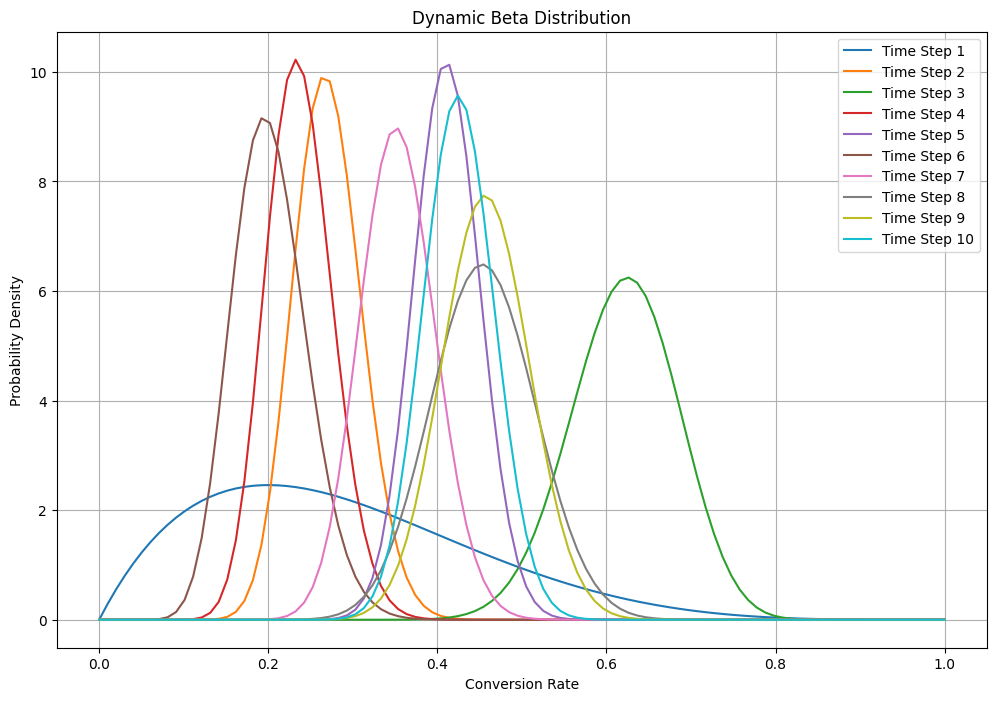

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameters
initial_alpha = 2  # Initial shape parameter (alpha) of the Beta distribution
initial_beta = 5   # Initial shape parameter (beta) of the Beta distribution
num_time_steps = 10  # Number of time steps to simulate

# Initialize arrays to store shape parameters and distributions
alphas = [initial_alpha]
betas = [initial_beta]
beta_distributions = [beta(initial_alpha, initial_beta)]

# Simulate the evolution of the Beta distribution over multiple time steps
for t in range(1, num_time_steps):
    # Example: Update shape parameters based on observed conversions and non-conversions
    observed_conversions = np.random.randint(10, 100)  # Simulated number of conversions
    observed_non_conversions = np.random.randint(10, 100)  # Simulated number of non-conversions  generating data...

    # Update shape parameters using observed data (e.g., using Bayesian updating)
    updated_alpha = initial_alpha + observed_conversions
    updated_beta = initial_beta + observed_non_conversions

    # Store updated shape parameters
    alphas.append(updated_alpha)
    betas.append(updated_beta)

    # Generate the Beta distribution with updated shape parameters
    beta_distribution = beta(updated_alpha, updated_beta)
    beta_distributions.append(beta_distribution)

# Visualize the changing Beta distribution over time
plt.figure(figsize=(12, 8))
for t in range(num_time_steps):
    plt.plot(np.linspace(0, 1, 100), beta_distributions[t].pdf(np.linspace(0, 1, 100)), label=f'Time Step {t+1}')

plt.title('Dynamic Beta Distribution')
plt.xlabel('Conversion Rate')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

In this code:

We initialize parameters such as the initial shape parameters (initial_alpha and initial_beta) of the Beta distribution and the number of time steps to simulate (num_time_steps).  
We simulate the evolution of the Beta distribution over multiple time steps. At each time step, we update the shape parameters based on simulated observations (e.g., conversions and non-conversions).  
We visualize the changing Beta distribution at each time step by plotting the probability density function (PDF) of the Beta distribution using Matplotlib.  

## 3. ADVANCED: Insights from Dynamic beta simulation

Here are some insights that can be gained from the dynamic Beta simulation and visualization:

Initial Conversion Rate Assessment:
At the beginning of the simulation (time step 1), the initial shape parameters of the Beta distribution represent the prior beliefs or assumptions about the conversion rate of the website.  
The initial Beta distribution reflects the uncertainty in the conversion rate before any user interactions or data collection.  

Evolution of Conversion Rate:
As the simulation progresses through multiple time steps, the shape of the Beta distribution evolves based on observed user interactions (e.g., conversions and non-conversions).  
The changes in the shape parameters (alpha and beta) reflect the updated beliefs about the conversion rate as more data becomes available.  
By visualizing the changing Beta distributions over time, we can observe how the uncertainty in the conversion rate decreases as more data is collected.  

Trends and Patterns:
Analyzing the trends and patterns in the dynamic Beta distributions can reveal insights into the website's performance and user behavior over time.  
For example, periods of increasing or decreasing conversion rates may indicate changes in website design, marketing strategies, or user engagement.  
Peaks or valleys in the Beta distributions may correspond to specific events or campaigns that impact user behavior and conversion rates.  

Identification of Significant Changes:
Significant changes in the shape of the Beta distribution may indicate critical points in the website's evolution or performance.  
Abrupt shifts in the distribution could signal the introduction of new features, changes in pricing, or external factors influencing user behavior.  
By closely examining these changes, stakeholders can identify factors driving fluctuations in conversion rates and make informed decisions to optimize website performance.  

Assessment of Interventions:
Comparing the Beta distributions before and after implementing interventions or changes on the website allows for the assessment of their effectiveness.  
A shift towards higher conversion rates following a specific intervention suggests its positive impact, while no significant change may indicate the need for further optimization or adjustment.  
Overall, the dynamic Beta simulation and visualization provide valuable insights into the evolution of the website's conversion rate, allowing stakeholders to make data-driven decisions to improve user engagement, optimize marketing strategies, and enhance overall performance.  